In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/TA_KIM/data')
dir = os.getcwd()
beta = f'{dir}/beta_avg_56_bd.txt'
ph = f'{dir}/ph_label_universal.txt'

Mounted at /content/drive


In [3]:
X_df = pd.read_csv(beta, delimiter=' ')
y_df = pd.read_csv(ph, delimiter=' ')
X = X_df.values
y = y_df['label'].values

In [4]:
X

array([[0.03081, 0.94396, 0.9298 , ..., 0.06821, 0.06902, 0.77728],
       [0.03405, 0.92225, 0.96381, ..., 0.04409, 0.06827, 0.63172],
       [0.02489, 0.92088, 0.94578, ..., 0.07238, 0.05818, 0.6318 ],
       ...,
       [0.02999, 0.93959, 0.9179 , ..., 0.09701, 0.12908, 0.6087 ],
       [0.02448, 0.92589, 0.59533, ..., 0.17141, 0.06123, 0.48763],
       [0.02945, 0.93956, 0.95654, ..., 0.038  , 0.21718, 0.38382]])

In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [8]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42) #set random seet for reproducibility
X_res, y_res = sm.fit_resample(X, y)
X_res = np.round(X_res, decimals = 5)
# Print the class distribution before and after SMOTE
print("Original class distribution:")
print({i: list(y).count(i) for i in range(len(set(y)))})
print("Class distribution after SMOTE:")
print({i: list(y_res).count(i) for i in range(len(set(y_res)))})

Original class distribution:
{0: 100, 1: 46, 2: 167, 3: 120}
Class distribution after SMOTE:
{0: 167, 1: 167, 2: 167, 3: 167}


In [9]:
X_res

array([[0.03081, 0.94396, 0.9298 , ..., 0.06821, 0.06902, 0.77728],
       [0.03405, 0.92225, 0.96381, ..., 0.04409, 0.06827, 0.63172],
       [0.02489, 0.92088, 0.94578, ..., 0.07238, 0.05818, 0.6318 ],
       ...,
       [0.03029, 0.91467, 0.90366, ..., 0.09882, 0.05642, 0.70428],
       [0.03247, 0.52895, 0.42782, ..., 0.06635, 0.15224, 0.81376],
       [0.02401, 0.95244, 0.92934, ..., 0.06584, 0.76835, 0.87036]])

In [ ]:
# Convert back to pandas DataFrame if necessary
X_sm = pd.DataFrame(X_res, columns= X_df.columns)
y_sm = pd.Series(y_res, name='label')

In [ ]:
X_sm

,AAAS,AACS,AANAT,AARSD1,AATK,ABCA10,ABCA12,ABCA17P,ABCA2,ABCA3,...,ZNF799,ZNF821,ZNF833,ZNFX1,ZNRD1,ZNRF1,ZNRF2,ZNRF3,ZPBP,ZSWIM6
0,0.03081,0.94396,0.92980,0.02454,0.81835,0.91343,0.63477,0.20126,0.97273,0.84826,...,0.02010,0.96100,0.46392,0.81022,0.84356,0.45222,0.72530,0.06821,0.06902,0.77728
1,0.03405,0.92225,0.96381,0.02405,0.71064,0.85897,0.65350,0.17049,0.96698,0.78839,...,0.02596,0.95359,0.43808,0.71008,0.80834,0.49521,0.72461,0.04409,0.06827,0.63172
2,0.02489,0.92088,0.94578,0.02888,0.73642,0.85548,0.57912,0.18279,0.95758,0.76651,...,0.02140,0.94847,0.36789,0.69702,0.67960,0.61135,0.78294,0.07238,0.05818,0.63180
3,0.03042,0.94342,0.94260,0.03325,0.72050,0.85553,0.74397,0.23618,0.95930,0.81556,...,0.01608,0.96995,0.41858,0.71437,0.76645,0.73121,0.78631,0.14072,0.04707,0.65719
4,0.02104,0.92132,0.90065,0.02203,0.74752,0.84382,0.54700,0.12181,0.95373,0.71517,...,0.02395,0.96420,0.39082,0.71967,0.71444,0.71011,0.74828,0.07474,0.10575,0.71189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,0.03416,0.89953,0.93613,0.03545,0.54360,0.75486,0.24122,0.02586,0.94911,0.85719,...,0.01560,0.96486,0.59783,0.81422,0.68263,0.57394,0.48292,0.04457,0.34096,0.80605
664,0.02583,0.91994,0.52705,0.04059,0.48022,0.76009,0.33230,0.03316,0.95099,0.72566,...,0.02166,0.96260,0.50911,0.84606,0.82673,0.92536,0.50018,0.04400,0.41856,0.82325
665,0.03029,0.91467,0.90366,0.02656,0.72396,0.79383,0.68477,0.03039,0.93784,0.80029,...,0.02336,0.96511,0.48743,0.75576,0.64264,0.83263,0.41825,0.09882,0.05642,0.70428
666,0.03247,0.52895,0.42782,0.02962,0.20204,0.72901,0.28303,0.25705,0.94949,0.40885,...,0.01224,0.96554,0.64664,0.85854,0.20835,0.43856,0.72467,0.06635,0.15224,0.81376


In [ ]:
y_sm

0      0
1      0
2      0
3      0
4      0
      ..
663    3
664    3
665    3
666    3
667    3
Name: label, Length: 668, dtype: int64

<br>

In [ ]:
X_run = X_sm.values
y_run = y_sm.values

In [ ]:
X_run

array([[0.03081, 0.94396, 0.9298 , ..., 0.06821, 0.06902, 0.77728],
       [0.03405, 0.92225, 0.96381, ..., 0.04409, 0.06827, 0.63172],
       [0.02489, 0.92088, 0.94578, ..., 0.07238, 0.05818, 0.6318 ],
       ...,
       [0.03029, 0.91467, 0.90366, ..., 0.09882, 0.05642, 0.70428],
       [0.03247, 0.52895, 0.42782, ..., 0.06635, 0.15224, 0.81376],
       [0.02401, 0.95244, 0.92934, ..., 0.06584, 0.76835, 0.87036]])

In [ ]:
y_run

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

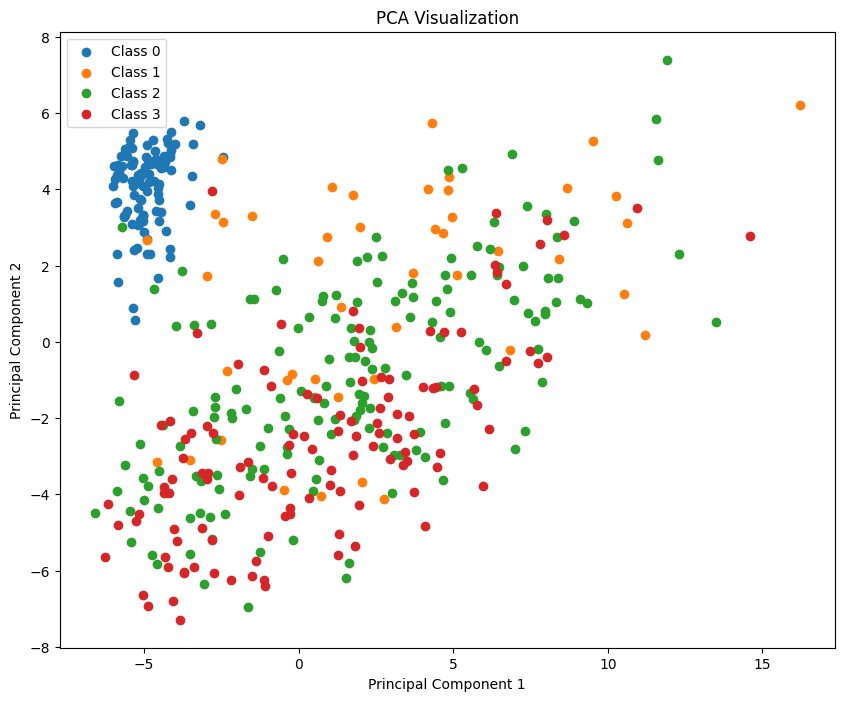

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 2: Perform PCA
pca = PCA(n_components=2)  # You can adjust the number of components as needed
X_pca = pca.fit_transform(X)

# Step 4: Visualize
plt.figure(figsize=(10, 8))
for i in range(len(np.unique(y))):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=f'Class {i}')

plt.title('PCA Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


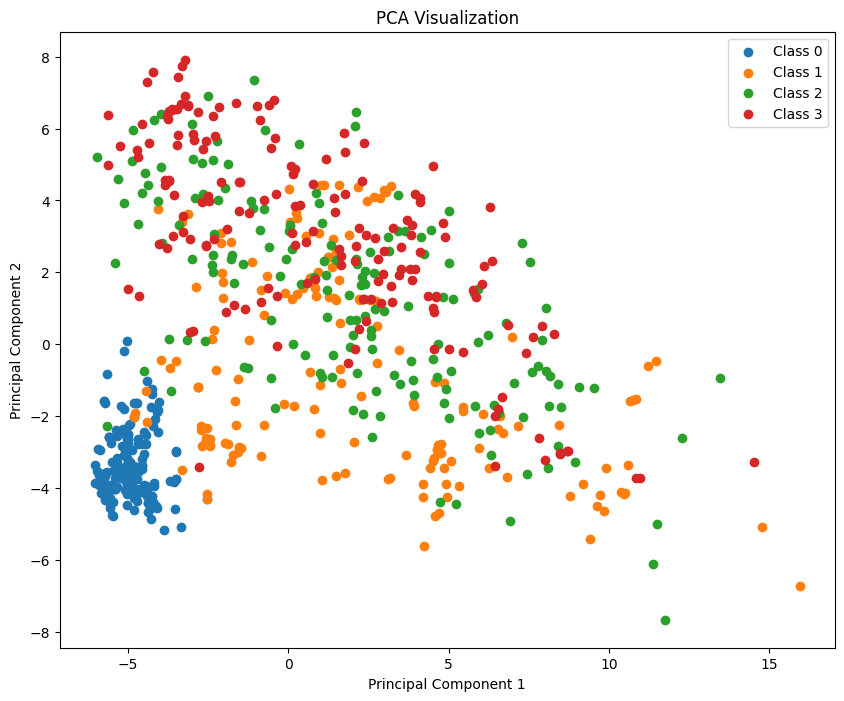

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 2: Perform PCA
pca = PCA(n_components=2)  # You can adjust the number of components as needed
X_pca = pca.fit_transform(X_run)

# Step 4: Visualize
plt.figure(figsize=(10, 8))
for i in range(len(np.unique(y_run))):
    plt.scatter(X_pca[y_run == i, 0], X_pca[y_run == i, 1], label=f'Class {i}')

plt.title('PCA Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


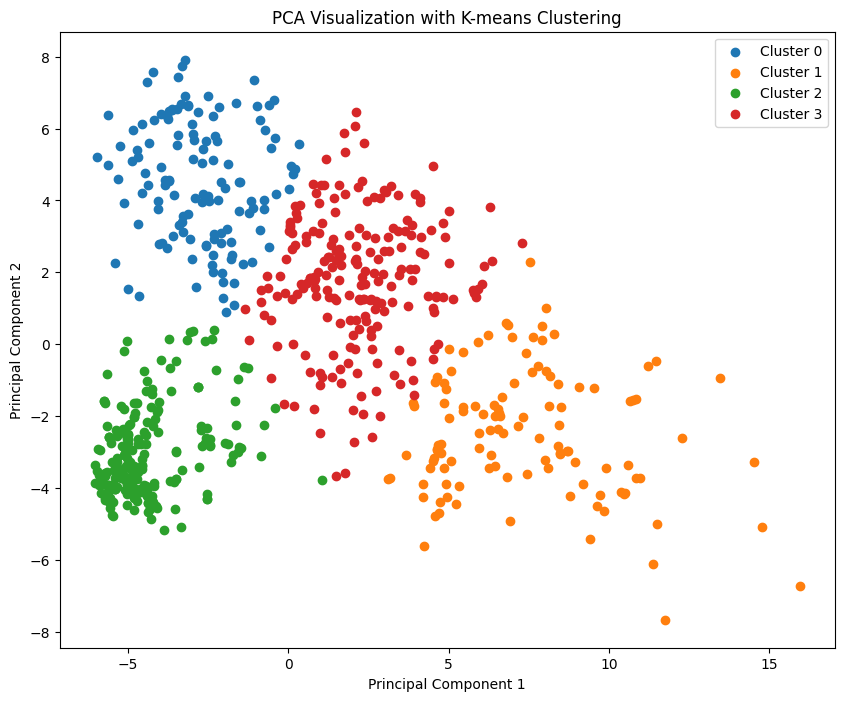

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 1: Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_run)

# Step 2: Perform K-means clustering
kmeans = KMeans(n_clusters=4)  # You can adjust the number of clusters as needed
kmeans.fit(X_pca)
cluster_labels = kmeans.labels_

# Step 3: Visualize
plt.figure(figsize=(10, 8))
for i in range(len(np.unique(cluster_labels))):
    plt.scatter(X_pca[cluster_labels == i, 0], X_pca[cluster_labels == i, 1], label=f'Cluster {i}')

plt.title('PCA Visualization with K-means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


In [ ]:
# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=1000, random_state=42)

# Initialize k-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Lists to store evaluation metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

In [ ]:
# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X_run[train_index], X_run[test_index]
    y_train, y_test = y_run[train_index], y_run[test_index]

    # Train the model
    rf_classifier.fit(X_train, y_train)

    # Make predictions
    predictions = rf_classifier.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    f1 = f1_score(y_test, predictions, average='weighted')

    # Append scores to lists
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    # Print evaluation metrics for each fold
    print(f"Fold {fold+1}: Accuracy={accuracy}, Precision={precision}, Recall={recall}, F1-score={f1}")


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Fold 1: Accuracy=0.7045454545454546, Precision=0.6875, Recall=0.7045454545454546, F1-score=0.6798659982647257


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Fold 2: Accuracy=0.6818181818181818, Precision=0.6283422459893049, Recall=0.6818181818181818, F1-score=0.6504702194357367


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

Fold 7: Accuracy=0.5581395348837209, Precision=0.46534883720930226, Recall=0.5581395348837209, F1-score=0.5017194148161099


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Fold 8: Accuracy=0.6976744186046512, Precision=0.6463178294573644, Recall=0.6976744186046512, F1-score=0.6604472042272442


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Fold 9: Accuracy=0.5116279069767442, Precision=0.49089147286821705, Recall=0.5116279069767442, F1-score=0.49712634011401474
Fold 10: Accuracy=0.7441860465116279, Precision=0.7629235880398672, Recall=0.7441860465116279, F1-score=0.7280844078828764


In [ ]:
# Calculate average scores across all folds and round to 3 decimals
avg_accuracy = round(np.mean(accuracy_scores), 3)
avg_precision = round(np.mean(precision_scores), 3)
avg_recall = round(np.mean(recall_scores), 3)
avg_f1 = round(np.mean(f1_scores), 3)

# Calculate standard deviation of scores across all folds and round to 3 decimals
std_accuracy = round(np.std(accuracy_scores), 3)
std_precision = round(np.std(precision_scores), 3)
std_recall = round(np.std(recall_scores), 3)
std_f1 = round(np.std(f1_scores), 3)

# Print average and standard deviation scores rounded to 3 decimals
print("\nAverage Scores Across all Folds:")
print(f"Accuracy: {avg_accuracy} +- {std_accuracy}")
print(f"Precision: {avg_precision} +- {std_precision}")
print(f"Recall: {avg_recall} +- {std_recall}")
print(f"F1-score: {avg_f1} +- {std_f1}")



Average Scores Across all Folds:
Accuracy: 0.626 +- 0.079
Precision: 0.59 +- 0.094
Recall: 0.626 +- 0.079
F1-score: 0.591 +- 0.081


<br>

**Hyperparameter**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

In [ ]:
# Define the parameter grid to search over
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20],  # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'max_features': ['auto', 'sqrt'],  # Number of features to consider when looking for the best split
    'bootstrap': [True, False]  # Whether bootstrap samples are used when building trees
}

# Initialize Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# Perform grid search
grid_search.fit(X_run, y_run)



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomFor

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20],
                         'max_features': ['auto', 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Print the best parameters and best score
print("Best Parameters:", best_params)
print("Best Score:", best_score)

Best Parameters: {'bootstrap': False, 'max_depth': 10, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.8070474694198181


<br>

In [ ]:
# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(bootstrap=False,
                                    max_depth=10,
                                    max_features='auto',
                                    min_samples_leaf=1,
                                    min_samples_split=2,
                                    n_estimators=100)

# Initialize k-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Lists to store evaluation metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

In [ ]:
# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X_run[train_index], X_run[test_index]
    y_train, y_test = y_run[train_index], y_run[test_index]

    # Train the model
    rf_classifier.fit(X_train, y_train)

    # Make predictions
    predictions = rf_classifier.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    f1 = f1_score(y_test, predictions, average='weighted')

    # Append scores to lists
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    # Print evaluation metrics for each fold
    print(f"Fold {fold+1}: Accuracy={accuracy}, Precision={precision}, Recall={recall}, F1-score={f1}")


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Fold 1: Accuracy=0.75, Precision=0.7272727272727273, Recall=0.75, F1-score=0.731025641025641
Fold 2: Accuracy=0.6818181818181818, Precision=0.6840909090909091, Recall=0.6818181818181818, F1-score=0.6738816738816739


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Fold 3: Accuracy=0.6590909090909091, Precision=0.558025308025308, Recall=0.6590909090909091, F1-score=0.5965353222628764


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


...

Fold 7: Accuracy=0.5581395348837209, Precision=0.47047522750252785, Recall=0.5581395348837209, F1-score=0.5087515299877602


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Fold 8: Accuracy=0.7209302325581395, Precision=0.6670037074486013, Recall=0.7209302325581395, F1-score=0.686046511627907


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Fold 9: Accuracy=0.46511627906976744, Precision=0.4505068574836017, Recall=0.46511627906976744, F1-score=0.44931709117755625
Fold 10: Accuracy=0.6511627906976745, Precision=0.6454508363933088, Recall=0.6511627906976745, F1-score=0.6475711591990663


In [ ]:
# Calculate average scores across all folds and round to 3 decimals
avg_accuracy = round(np.mean(accuracy_scores), 3)
avg_precision = round(np.mean(precision_scores), 3)
avg_recall = round(np.mean(recall_scores), 3)
avg_f1 = round(np.mean(f1_scores), 3)

# Calculate standard deviation of scores across all folds and round to 3 decimals
std_accuracy = round(np.std(accuracy_scores), 3)
std_precision = round(np.std(precision_scores), 3)
std_recall = round(np.std(recall_scores), 3)
std_f1 = round(np.std(f1_scores), 3)

# Print average and standard deviation scores rounded to 3 decimals
print("\nAverage Scores Across all Folds:")
print(f"Accuracy: {avg_accuracy} +- {std_accuracy}")
print(f"Precision: {avg_precision} +- {std_precision}")
print(f"Recall: {avg_recall} +- {std_recall}")
print(f"F1-score: {avg_f1} +- {std_f1}")



Average Scores Across all Folds:
Accuracy: 0.623 +- 0.084
Precision: 0.591 +- 0.086
Recall: 0.623 +- 0.084
F1-score: 0.594 +- 0.086
